In [17]:
import numpy as np
import matplotlib.pyplot as plt
green = '#89de56'
red = '#e44a83'
yellow = '#e4c94a'
blue = '#4a99e4'

### Funktion zum Einlesen einer CSV-Datei und Berechnung des Mittelwerts und der Standardabweichung

In [41]:
def read_csv_file(filename, skip_header=1000, num_samples=50000):
    # Einlesen der Datei
    data = np.genfromtxt(
        filename,
        delimiter=';',
        skip_header=skip_header,
        converters={0: lambda s: float(s.decode().replace(',', '.')),
                    1: lambda s: float(s.decode().replace(',', '.'))}
    )

    relevant_data = data[:num_samples, 1]   # Auswahl der relevanten Daten
    mean = np.mean(relevant_data)           # Berechnung des Mittelwerts
    std_dev = np.std(relevant_data)         # Berechnung der Standardabweichung
    return mean, std_dev

### Funktion zur Darstellung der Messungen

In [19]:
def plot_measurements(x, y, std_dev, title):
    plt.errorbar(x, y, yerr=std_dev, fmt='o', linestyle='--', label='Messungung von 1 bis 20', color=green)

    # Plot-Einstellungen
    plt.xlabel('Spannung (V)')
    plt.ylabel('Distanz (cm)')
    plt.title(title)
    plt.legend(loc='upper right', fontsize='small', fancybox=True)
    plt.grid(True)
    plt.show()

### Durchlaufen aller Dateien von Messung001 bis Messung020

In [42]:
x_data = []                     # Spannungswerte
y_data = list(range(10, 70, 3)) # Distanzwerte
std_devs = []
for i in range(1, 21):
    filename = f"messungen/Messung{i:03d}.csv"

    mean, std_dev = read_csv_file(filename)
    x_data.append(mean)
    std_devs.append(std_dev)

    print(f"Spannung bei {y_data[i-1]} cm: {mean:.2f} V ± {std_dev:.2f} V")

Spannung bei 10 cm: 1.41 V ± 0.02 V
Spannung bei 13 cm: 1.25 V ± 0.02 V
Spannung bei 16 cm: 1.10 V ± 0.02 V
Spannung bei 19 cm: 1.00 V ± 0.02 V
Spannung bei 22 cm: 0.93 V ± 0.02 V
Spannung bei 25 cm: 0.86 V ± 0.02 V
Spannung bei 28 cm: 0.82 V ± 0.02 V
Spannung bei 31 cm: 0.76 V ± 0.02 V
Spannung bei 34 cm: 0.74 V ± 0.02 V
Spannung bei 37 cm: 0.70 V ± 0.02 V
Spannung bei 40 cm: 0.70 V ± 0.02 V
Spannung bei 43 cm: 0.68 V ± 0.02 V
Spannung bei 46 cm: 0.64 V ± 0.02 V
Spannung bei 49 cm: 0.64 V ± 0.02 V
Spannung bei 52 cm: 0.62 V ± 0.02 V
Spannung bei 55 cm: 0.60 V ± 0.02 V
Spannung bei 58 cm: 0.58 V ± 0.02 V
Spannung bei 61 cm: 0.56 V ± 0.01 V
Spannung bei 64 cm: 0.55 V ± 0.02 V
Spannung bei 67 cm: 0.52 V ± 0.02 V


Darstellung der Messungen mit Fehlerbalken für die Standardabweichung: 

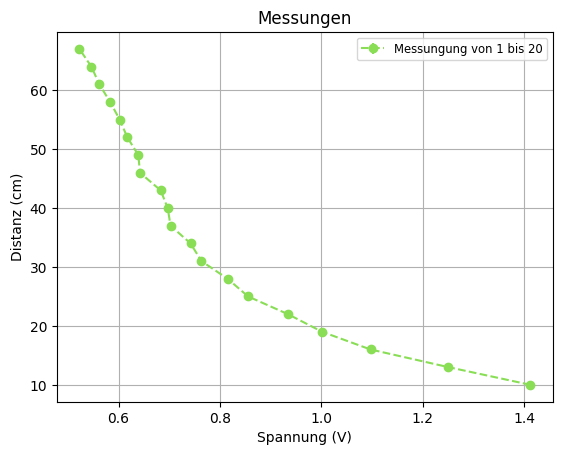

In [43]:
plot_measurements(x_data, y_data, std_devs, "Messungen")

### Funktion zur Berechnung der linearen Regression

In [25]:
def logarithmic_linear_regression(x, y):
    x_log = np.log(x)                   # Logarithmieren der x-Werte
    y_log = np.log(y)                   # Logarithmieren der y-Werte
    a, b = np.polyfit(x_log, y_log, 1)  # Berechnung der linearen Regression
    r = np.corrcoef(x_log, y_log)[0, 1] # Berechnung des Korrelationskoeffiz
    return a, b, r

### Funktion zur Darstellung der linearen Regression

In [39]:
def plot_function_data(x, y, x_data, y_data, title, r,
                       color=red, color_data=blue, linestyle='-'):
    plt.plot(x, y, linestyle=linestyle, color=color, label='Mean')
    plt.scatter(x_data, y_data, color=color_data, label='Datenpunkte')
    plt.xlabel('Spannung (V)')
    plt.ylabel('Distanz (cm)')
    l = plt.legend(loc='upper right', fontsize='small', fancybox=True)
    l.get_texts()[0].set_text(f'Lineare Regression mit r^2={r:.4f}')
    plt.title(title)
    plt.grid(True)
    plt.show()

## Berechnung der linearen Regression und Darstellung der Ergebnisse

Linear regression: a=-1.9825162461824637, b=2.9595702629844345, r=-0.9978213533626266


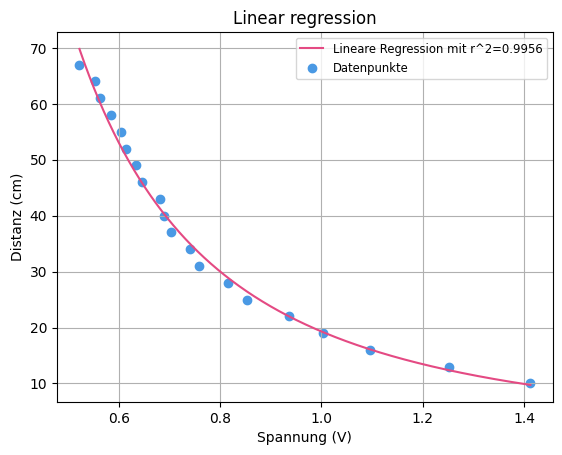

In [40]:
a, b, r = logarithmic_linear_regression(x_data, y_data)
print(f"Linear regression: a={a}, b={b}, r={r}")

x = np.linspace(x_data[0], x_data[-1], 1000)
y = np.exp(b) * x ** a
plot_function_data(x, y, x_data, y_data, "Linear regression", r**2)